# Machine Learning for Lung Cancer Prediction: An End-to-End Classification Exercise


## Objective
Develop and evaluate a supervised classification model that predicts lung cancer from patient symptoms and determine the critical predictive features from the provided dataset.



<!-- generated-team-badges: run `python scripts/update_notebook_badges.py` to refresh -->
<div align="center"><img alt="Hours" src="https://img.shields.io/badge/Hours-8h%2014m-4A4A4A?style=flat-square&logo=git&logoColor=white&labelColor=1F6FEB" /> <a href="https://github.com/jamesbarlow1812"><img alt="James Barlow" src="https://img.shields.io/badge/%20-James%20Barlow-4A4A4A?style=flat-square&logo=github&logoColor=white&labelColor=7C3AED" /></a> <a href="https://github.com/JoeShade"><img alt="Joe Shade" src="https://img.shields.io/badge/%20-Joe%20Shade-4A4A4A?style=flat-square&logo=github&logoColor=white&labelColor=D97706" /></a> <a href="https://github.com/Nomo2001"><img alt="Lena Kraemer" src="https://img.shields.io/badge/%20-Lena%20Kraemer-4A4A4A?style=flat-square&logo=github&logoColor=white&labelColor=059669" /></a> <a href="https://github.com/SimonAndreou"><img alt="Simon Andreou" src="https://img.shields.io/badge/%20-Simon%20Andreou-4A4A4A?style=flat-square&logo=github&logoColor=white&labelColor=DC2626" /></a></div>




<table style="margin-left: auto; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: center;">Team member</th>
      <th style="text-align: center;">Main responsibility</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: center;">James Barlow</td>
      <td style="text-align: center;">Feature Engineer</td>
    </tr>
    <tr>
      <td style="text-align: center;">Joe Shade</td>
      <td style="text-align: center;">Coding, repo governance</td>
    </tr>
    <tr>
      <td style="text-align: center;">Lena Kraemer</td>
      <td style="text-align: center;">ML Engineer, Model Builder</td>
    </tr>
    <tr>
      <td style="text-align: center;">Simon Andreou</td>
      <td style="text-align: center;">Data Scientist/ Coordinator</td>
    </tr>
  </tbody>
</table>

<p style="text-align: center;"><em>Table 1, Student Contribution Matrix</em></p>

## 1. Problem Definition and Plan


### 1.1 ML task definition

The machine learning task is a supervised binary classification, the target variable is "LUNG_CANCER" which is either true or false. We want to learn a mapping from patient feature to the target label so that the model can classify whether a patient record is indicative of lung cancer, yes or no. 

Due to the severe imbalance in the data set accuracy alone is not a sufficient metric to evaluate the model. A model can get high accuracy by overpredicting the majorirty class. 

### 1.2 Why this problem matters




Lung cancer is a serious health condition, improving how high-risk cases are identified may have a positive impact on health outcomes. 
Through this exercise we can also identify what features are strong indicators of lung cancer. 

Academically this challenge is also valuable, it is a strong example of responsible machine learning practice. The importance of context and real life consequences of poor engineering thinking. 

# 2. Data Preparation


## 2.1 Dataset overview
The notebook uses `datasets/givenData.csv` as the canonical input file. The raw dataset contains 309 rows and 16 columns: one binary target (`LUNG_CANCER`), one age field, one gender field, and 13 symptom or lifestyle indicators. `LUNG_CANCER` is the label the models will try to predict, while the remaining columns are candidate features available before prediction.


In [35]:
# import Python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import the Scikit-Learn framework
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler


In [36]:
dataset = pd.read_csv("datasets/givenData.csv", thousands=",")
dataset.columns = dataset.columns.str.strip()

dataset.head(10)

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
5,F,75,1,2,1,1,2,2,2,2,1,2,2,1,1,YES
6,M,52,2,1,1,1,1,2,1,2,2,2,2,1,2,YES
7,F,51,2,2,2,2,1,2,2,1,1,1,2,2,1,YES
8,F,68,2,1,2,1,1,2,1,1,1,1,1,1,1,NO
9,M,53,2,2,2,2,2,1,2,1,2,1,1,2,2,YES


<p style="text-align: center;"><em>Table 2, Raw data preview</em></p>

### 2.1.1 Column definitions
<table style='width: 100%; border-collapse: collapse; border-spacing: 0; border: none !important; font-size: 14px; color: #000000;'>
  <thead>
    <tr style='background-color: #eceaea; color: #000000;'>
      <th style='padding: 8px; text-align: left; border: none !important;'>COLUMN</th>
      <th style='padding: 8px; text-align: left; border: none !important;'>TYPE</th>
      <th style='padding: 8px; text-align: left; border: none !important;'>NOTES</th>
      <th style='padding: 8px; text-align: left; border: none !important;'>RAW ENCODING</th>
      <th style='padding: 8px; text-align: left; border: none !important;'>NEW ENCODING</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>LUNG_CANCER</code></td><td style='padding: 8px; border: none !important;'>Binary target</td><td style='padding: 8px; border: none !important;'>Whether the patient is labelled as having lung cancer</td><td style='padding: 8px; border: none !important;'><code>YES</code> / <code>NO</code></td><td style='padding: 8px; border: none !important;'><code>1</code> = cancer, <code>0</code> = no cancer</td></tr>
    <tr><td colspan='5' style='padding: 8px; border: none !important; background-color: #eceaea; color: #000000; font-weight: bold; text-align: center;'>PREDICTOR VARIABLES</td></tr>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>GENDER</code></td><td style='padding: 8px; border: none !important;'>Categorical</td><td style='padding: 8px; border: none !important;'>Recorded patient sex/gender</td><td style='padding: 8px; border: none !important;'><code>M</code> / <code>F</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = male, <code>1</code> = female</td></tr>
    <tr style='background-color: #f4f2f2;'><td style='padding: 8px; border: none !important;'><code>AGE</code></td><td style='padding: 8px; border: none !important;'>Numeric</td><td style='padding: 8px; border: none !important;'>Patient age in years</td><td style='padding: 8px; border: none !important;'>Integer-valued</td><td style='padding: 8px; border: none !important;'>Kept numeric; later min-max scaled in the model pipeline</td></tr>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>SMOKING</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether the patient is recorded as smoking</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code> in the raw data</td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #f4f2f2;'><td style='padding: 8px; border: none !important;'><code>YELLOW_FINGERS</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether yellow fingers are recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>ANXIETY</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether anxiety is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #f4f2f2;'><td style='padding: 8px; border: none !important;'><code>PEER_PRESSURE</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether peer pressure is recorded as a factor</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>CHRONIC DISEASE</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether chronic disease is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #f4f2f2;'><td style='padding: 8px; border: none !important;'><code>FATIGUE </code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether fatigue is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>ALLERGY </code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether allergy is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #f4f2f2;'><td style='padding: 8px; border: none !important;'><code>WHEEZING</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether wheezing is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>ALCOHOL CONSUMING</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether alcohol consumption is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #f4f2f2;'><td style='padding: 8px; border: none !important;'><code>COUGHING</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether coughing is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>SHORTNESS OF BREATH</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether shortness of breath is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #f4f2f2;'><td style='padding: 8px; border: none !important;'><code>SWALLOWING DIFFICULTY</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether swallowing difficulty is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
    <tr style='background-color: #fbfbfb;'><td style='padding: 8px; border: none !important;'><code>CHEST PAIN</code></td><td style='padding: 8px; border: none !important;'>Binary indicator</td><td style='padding: 8px; border: none !important;'>Whether chest pain is recorded as present</td><td style='padding: 8px; border: none !important;'>Encoded as <code>1</code>/<code>2</code></td><td style='padding: 8px; border: none !important;'><code>0</code> = no, <code>1</code> = yes</td></tr>
  </tbody>
</table>
<p style='text-align: center; margin-top: 8px; color: #000000;'><em>Table 3, Raw column definitions</em></p>

**Note:** Most non-target binary variables are encoded as <code>1</code>/<code>2</code> rather than <code>0</code>/<code>1</code>, a few  column names contain spacing issues.

### 2.1.2 Initial observations
First inspection showed three practical preparation issues: duplicated rows, several column names with spaces or trailing whitespace, and binary variables encoded as `1/2` rather than `0/1`. These need explicit handling before being parsed to the model.


## 2.2 Data quality checks



### 2.2.1 Missing data
No missing values were found in the raw file. Preparation therefore focuses on duplicate handling, consistent recoding, and a small amount of interpretable feature engineering rather than imputation.


In [37]:
# Summarise completeness and data types, then render a centred HTML table
try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

missing_data_summary = pd.DataFrame(
    {
        "Column": dataset.columns,
        "Data type": dataset.dtypes.astype(str).values,
        "Non-null count": dataset.notna().sum().values,
        "Missing values": dataset.isna().sum().values,
    }
)

missing_data_summary["Completeness (%)"] = (
    missing_data_summary["Non-null count"] / len(dataset) * 100
).round(1)

target_row = missing_data_summary.loc[
    missing_data_summary["Column"] == "LUNG_CANCER"
].copy()
predictor_rows = missing_data_summary.loc[
    missing_data_summary["Column"] != "LUNG_CANCER"
].copy()

def _summary_row_to_html(row: pd.Series, background: str) -> str:
    return (
        f"<tr style='background-color: {background};'>"
        f"<td style='padding: 8px; border: none !important;'><code>{row['Column']}</code></td>"
        f"<td style='padding: 8px; border: none !important;'>{row['Data type']}</td>"
        f"<td style='padding: 8px; border: none !important;'>{row['Non-null count']}</td>"
        f"<td style='padding: 8px; border: none !important;'>{row['Missing values']}</td>"
        f"<td style='padding: 8px; border: none !important;'>{row['Completeness (%)']:.1f}%</td>"
        "</tr>"
    )

html_rows = []
html_rows.append(_summary_row_to_html(target_row.iloc[0], "#fbfbfb"))
html_rows.append(
    "<tr><td colspan='5' style='padding: 8px; border: none !important; "
    "background-color: #eceaea; color: #000000; font-weight: bold; text-align: center;'>"
    "PREDICTOR VARIABLES"
    "</td></tr>"
)

for index, (_, row) in enumerate(predictor_rows.iterrows()):
    background = "#fbfbfb" if index % 2 == 0 else "#f4f2f2"
    html_rows.append(_summary_row_to_html(row, background))

missing_data_summary_html = "".join(
    [
        "<div style='width: 100%; text-align: center;'>",
        "<table style='width: 92%; margin: 0 auto; border-collapse: collapse; "
        "border-spacing: 0; border: none !important; font-size: 14px; color: #000000;'>",
        "<thead>",
        "<tr style='background-color: #eceaea; color: #000000;'>",
        "<th style='padding: 8px; text-align: left; border: none !important;'>COLUMN</th>",
        "<th style='padding: 8px; text-align: left; border: none !important;'>DATA TYPE</th>",
        "<th style='padding: 8px; text-align: left; border: none !important;'>NON-NULL COUNT</th>",
        "<th style='padding: 8px; text-align: left; border: none !important;'>MISSING VALUES</th>",
        "<th style='padding: 8px; text-align: left; border: none !important;'>COMPLETENESS (%)</th>",
        "</tr>",
        "</thead>",
        "<tbody>",
        *html_rows,
        "</tbody>",
        "</table>",
        "</div>",
    ]
)

if HTML is not None and display is not None:
    display(HTML(missing_data_summary_html))
else:
    print(missing_data_summary.to_string(index=False))

<p style='text-align: center; margin-top: 8px; color: #000000;'><em>Table 4, Data completeness summary</em></p>

### 2.2.2 De-duplication
The raw dataset contains 309 rows, with a duplicate-heavy block at the end of the file. Within the final 30 raw rows, 25 are flagged as exact duplicates of earlier records, while only 8 exact duplicate flags appear across all earlier rows combined. For this notebook, the final 30 rows are treated as the most likely erroneous appended segment and removed as a whole, including the five rows in that block that are not individually flagged by `duplicated()`. Earlier repeated rows are retained on the assumption that they belong to the original dataset rather than to the later append. This rule leaves 279 rows in the working dataset for the remaining analysis.


In [38]:
# Summarise the final-row trimming decision in a centred HTML table.
try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

duplicate_flags = dataset.duplicated()
raw_row_count = len(dataset)
duplicate_row_count = int(duplicate_flags.sum())
final_block_size = 30
working_row_count = raw_row_count - final_block_size
retained_earlier_duplicate_count = int(dataset.iloc[:-final_block_size].duplicated().sum())

def _render_centered_html_table(
    table_df: pd.DataFrame, caption: str, width: str = "70%"
) -> str:
    header_html = "".join(
        f"<th style='padding: 8px; text-align: center; border: none !important;'>{column.upper()}</th>"
        for column in table_df.columns
    )

    body_rows = []
    for index, (_, row) in enumerate(table_df.iterrows()):
        background = "#fbfbfb" if index % 2 == 0 else "#f4f2f2"
        row_html = "".join(
            f"<td style='padding: 8px; text-align: center; border: none !important;'>{value}</td>"
            for value in row
        )
        body_rows.append(f"<tr style='background-color: {background};'>{row_html}</tr>")

    return "".join(
        [
            "<div style='width: 100%; text-align: center;'>",
            f"<table style='width: {width}; margin: 0 auto; border-collapse: collapse; border-spacing: 0; border: none !important; font-size: 14px; color: #000000;'>",
            "<thead>",
            "<tr style='background-color: #eceaea; color: #000000;'>",
            header_html,
            "</tr>",
            "</thead>",
            "<tbody>",
            *body_rows,
            "</tbody>",
            "</table>",
            f"<p style='text-align: center; margin-top: 8px; color: #000000;'><em>{caption}</em></p>",
            "</div>",
        ]
    )

dedup_summary_df = pd.DataFrame(
    {
        "Metric": [
            "Raw rows",
            "Final raw rows removed",
            "Working rows after removal",
            "Exact duplicate flags within full raw file",
            "Exact duplicate flags retained earlier in file",
            "Rule applied",
        ],
        "Value": [
            raw_row_count,
            final_block_size,
            working_row_count,
            duplicate_row_count,
            retained_earlier_duplicate_count,
            "Exclude the final <code>30</code> raw rows as one block",
        ],
    }
)

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        dedup_summary_df,
        "Table 5, De-duplication summary",
        width="72%",
    )))
else:
    print(dedup_summary_df.to_string(index=False))


METRIC,VALUE
Raw rows,309
Final raw rows removed,30
Working rows after removal,279
Exact duplicate flags within full raw file,33
Exact duplicate flags retained earlier in file,8
Rule applied,Exclude the final 30 raw rows as one block


In [39]:
# Show why the final block was treated as the suspicious appended segment.
final_segment_size = final_block_size
final_segment_duplicate_count = int(duplicate_flags.tail(final_segment_size).sum())
earlier_segment_size = raw_row_count - final_segment_size
earlier_segment_duplicate_count = duplicate_row_count - final_segment_duplicate_count

duplicate_distribution_df = pd.DataFrame(
    {
        "Location in raw file": [
            f"Final {final_segment_size} raw rows",
            "Earlier raw rows",
        ],
        "Rows flagged by duplicated()": [
            f"{final_segment_duplicate_count} of {final_segment_size}",
            f"{earlier_segment_duplicate_count} of {earlier_segment_size}",
        ],
        "Flagged share": [
            f"{final_segment_duplicate_count / final_segment_size * 100:.1f}%",
            f"{earlier_segment_duplicate_count / earlier_segment_size * 100:.1f}%",
        ],
    }
)

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        duplicate_distribution_df,
        "Table 6, Duplicate distribution evidence",
        width="68%",
    )))
else:
    print(duplicate_distribution_df.to_string(index=False))


LOCATION IN RAW FILE,ROWS FLAGGED BY DUPLICATED(),FLAGGED SHARE
Final 30 raw rows,25 of 30,83.3%
Earlier raw rows,8 of 279,2.9%


These two tables support treating the final 30 rows as the suspicious appended block. The notebook therefore excludes that whole tail segment from modelling, while leaving earlier repeated rows unchanged.


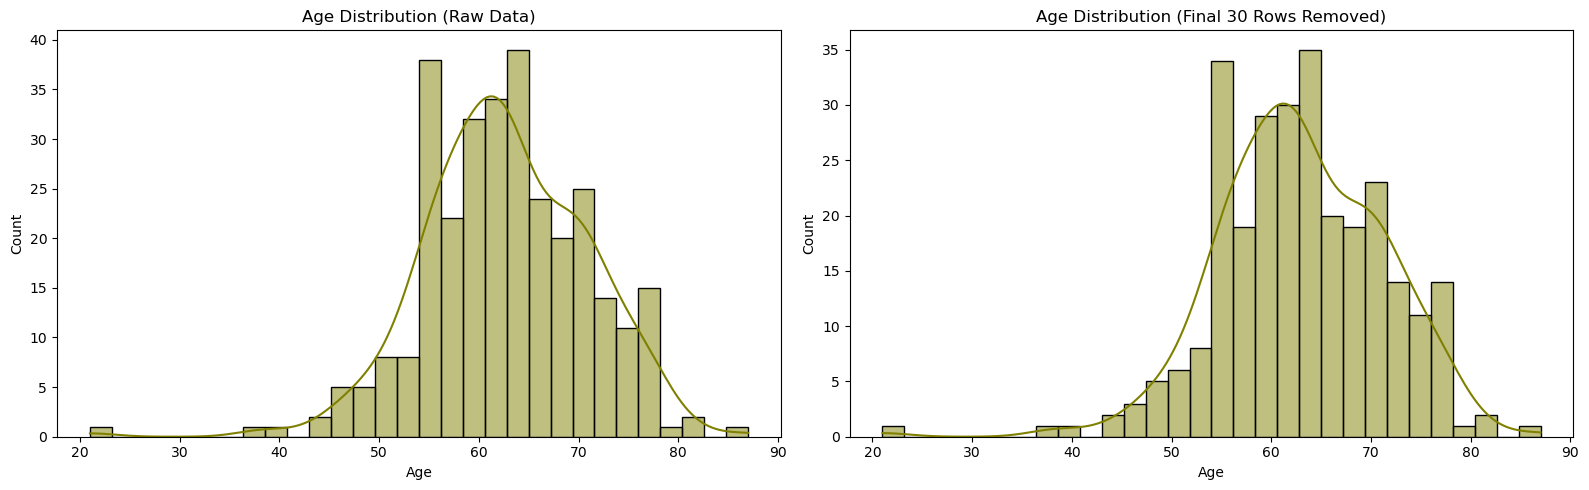

In [40]:
# Build the working dataset by excluding the suspicious final 30-row block.
dataset_dedup = dataset.iloc[:-30].reset_index(drop=True).copy()

# Compare the age distribution before and after removing the final raw-row block.
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=dataset, x='AGE', bins=30, kde=True, color='olive')
plt.title('Age Distribution (Raw Data)')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(data=dataset_dedup, x='AGE', bins=30, kde=True, color='olive')
plt.title('Age Distribution (Final 30 Rows Removed)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


<p style='text-align: center;'><em>Figure 3. Age distribution before and after removing the final 30 rows.</em></p>

The two histograms retain a very similar overall shape after the final 30 rows are removed, with no obvious shift in the main concentration of ages. This suggests that the de-duplication step reduces the influence of the suspicious appended block without materially changing the age profile of the working dataset, so later modelling is less exposed to duplicate-driven bias while remaining representative of the original sample structure.


## 2.2.3 Outlier review
Only `AGE` required a conventional outlier check because the remaining predictors are binary or categorical. We reviewed the age distribution on the working dataset after excluding the final 30 raw rows and used an interquartile-range rule to identify outliers.


### 2.2.3.1 Age outliers
The IQR rule flags four ages outside the approximate 40.9 to 85.9 range: 21, 38, 39, and 87. These values are unusual relative to the middle of the sample, but they are still plausible ages rather than obvious errors. The youngest flagged record is a 21-year-old female, which is unusual in this dataset but still credible enough to discuss rather than discard automatically.


### 2.2.3.2 Decision on outliers
No age records were removed. With only one continuous predictor, deleting rare but plausible ages would shrink an already small dataset and risk hiding real variation, so the notebook keeps all observed ages, including the 21-year-old female case, and treats them as part of the sample spread.


## 2.2.4 Encoding and preprocessing decisions
Most predictors are already categorical or binary in meaning, but the raw file stores them in a form that still needs consistent recoding. We standardised column names, mapped the target to `0/1`, recoded the binary predictors to `0/1`, and kept the final learned preprocessing steps inside the later modelling pipelines.

### 2.2.4.1 Target encoding
The target variable was originally stored as text (`YES` and `NO`). It was converted to binary form (`1` for lung cancer and `0` for no lung cancer) so that the classifiers and evaluation metrics can operate consistently.

### 2.2.4.2 Feature encoding
The symptom and lifestyle predictors were recoded from `1/2` to `0/1`, and `GENDER` was mapped from `M/F` to `0/1`. `AGE` remains numeric in the working dataset but is min-max normalised to the `0-1` range inside the shared preprocessing pipeline, while `AGE_BINS` is retained as a categorical feature and one-hot encoded there as well.

### 2.2.4.3 Scaling strategy
Scaling is useful for the logistic-regression baseline and harmless when applied consistently across models, so numeric features are standardised inside the common pipeline. Tree-based models do not need scaling for correctness, but using the same preprocessing structure keeps the comparison fair and leakage-safe.

### 2.2.4.4 Leakage prevention
All learned preprocessing steps are fitted only inside the training folds during cross-validation and only on the training split during final evaluation. This prevents the test data from influencing age normalisation, one-hot encoding, or any other fitted transformation before scoring.

### 2.2.5 Data consistency




In [41]:
dataset_clean = dataset_dedup.copy()

dataset_clean.columns = dataset_clean.columns.str.strip()
dataset_clean.rename(columns={'CHRONIC DISEASE': 'CHRONIC_DISEASE', 
                              'ALCOHOL CONSUMING': 'ALCOHOL_CONSUMING', 
                              'SHORTNESS OF BREATH': 'SHORTNESS_OF_BREATH', 
                              'SWALLOWING DIFFICULTY': 'SWALLOWING_DIFFICULTY', 
                              'CHEST PAIN': 'CHEST_PAIN'}, 
                              inplace=True)

# 0 = no, 1 = yes
binary_yes_no_cols = [
    'SMOKING',
    'YELLOW_FINGERS',
    'ANXIETY',
    'PEER_PRESSURE',
    'CHRONIC_DISEASE',
    'FATIGUE',
    'ALLERGY',
    'WHEEZING',
    'ALCOHOL_CONSUMING',
    'COUGHING',
    'SHORTNESS_OF_BREATH',
    'SWALLOWING_DIFFICULTY',
    'CHEST_PAIN'
]
dataset_clean[binary_yes_no_cols] = dataset_clean[binary_yes_no_cols] - 1

# 0 = male, 1 = female
dataset_clean['GENDER'] = dataset_clean['GENDER'].map({'M': 0, 'F': 1})

# 0 = no, 1 = yes
dataset_clean['LUNG_CANCER'] = dataset_clean['LUNG_CANCER'].map({'NO': 0, 'YES': 1})

# AGE is kept numeric in the working table and min-max normalised later
# inside the shared preprocessing pipeline so the fitted scaling remains
# leakage-safe during cross-validation and final evaluation.

dataset_clean_preview_df = dataset_clean.head(10)

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        dataset_clean_preview_df,
        "Table 7, Working dataset preview after consistency checks",
        width="92%",
    )))
else:
    print(dataset_clean_preview_df.to_string(index=False))


GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
0,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
1,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
0,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
1,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0
1,75,0,1,0,0,1,1,1,1,0,1,1,0,0,1
0,52,1,0,0,0,0,1,0,1,1,1,1,0,1,1
1,51,1,1,1,1,0,1,1,0,0,0,1,1,0,1
1,68,1,0,1,0,0,1,0,0,0,0,0,0,0,0
0,53,1,1,1,1,1,0,1,0,1,0,0,1,1,1


**Note:** Most non-target binary variables were recoded from <code>1</code>/<code>2</code> to <code>0</code>/<code>1</code>, and several column names were standardised to remove spacing inconsistencies. <code>AGE</code> remains numeric in this working table for inspection and interpretation, while its later min-max normalisation is handled inside the shared preprocessing pipeline so the fitted scaling stays leakage-safe.


## 2.3 Working variables used in the analysis workflow
This section creates provisional derived variables so that the later univariate and bivariate analysis can test whether they are useful enough to retain. The final feature-engineering decisions are then stated in Section 4.10 after the EDA evidence has been reviewed.


### 2.3.1 Provisional composite variables
`BATCH_1`, `BATCH_2`, and `BATCH_3` are constructed here as candidate grouped signals that can be evaluated in Section 4. They are not treated as final feature-engineering decisions at this stage; instead, the later EDA is used to judge whether the correlation-based groupings are defensible enough to keep.


In [42]:
# Build three batch-derived composite features from the strongest correlated groups found later in Section 4.5.1.
dataset_clean['BATCH_1'] = dataset_clean[
    ['ANXIETY', 'YELLOW_FINGERS', 'SWALLOWING_DIFFICULTY', 'PEER_PRESSURE']
].sum(axis=1)
dataset_clean['BATCH_2'] = dataset_clean[
    ['ALCOHOL_CONSUMING', 'CHEST_PAIN', 'ALLERGY']
].sum(axis=1)
dataset_clean['BATCH_3'] = dataset_clean[
    ['SHORTNESS_OF_BREATH', 'FATIGUE', 'COUGHING']
].sum(axis=1)
dataset_clean['AGE_BINS'] = pd.cut(
    dataset_clean['AGE'],
    bins=[0, 50, 60, 70, 80, 100],
    labels=['0', '1', '2', '3', '4'],
)

dataset_clean.head(25)


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER,BATCH_1,BATCH_2,BATCH_3,AGE_BINS
0,0,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1,3,2,3,2
1,0,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1,1,2,2,3
2,1,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0,1,1,3,1
3,0,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0,3,2,0,2
4,1,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0,1,0,2,2
5,1,75,0,1,0,0,1,1,1,1,0,1,1,0,0,1,1,1,3,3
6,0,52,1,0,0,0,0,1,0,1,1,1,1,0,1,1,0,2,3,1
7,1,51,1,1,1,1,0,1,1,0,0,0,1,1,0,1,4,1,2,1
8,1,68,1,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,2
9,0,53,1,1,1,1,1,0,1,0,1,0,0,1,1,1,4,3,0,1


### 2.3.2 Working age bands
Age was binned into `0-50`, `51-60`, `61-70`, `71-80`, and `81-100` so the later analysis can compare a grouped age view with the raw numeric variable. This grouped version is carried forward provisionally for evaluation rather than being justified before the EDA.


### 2.3.3 Analysis table before the final feature decision
No extra derived variables are committed beyond these provisional composites and age bands before Section 4.10. This keeps the analysis table broad enough to inspect candidate structure without locking in additional interactions too early.


In [43]:
engineered_feature_mean_df = (
    dataset_clean.groupby('LUNG_CANCER')[['BATCH_1', 'BATCH_2', 'BATCH_3']]
    .mean()
    .T.rename(columns={0: 'No Cancer Mean', 1: 'Cancer Mean'})
    .round(3)
)

engineered_feature_mean_df


LUNG_CANCER,No Cancer Mean,Cancer Mean
BATCH_1,1.057,2.172
BATCH_2,0.571,1.836
BATCH_3,1.286,1.959


In [44]:
engineered_correlation_df = dataset_clean[
    ['AGE', 'BATCH_1', 'BATCH_2', 'BATCH_3', 'LUNG_CANCER']
].corr(numeric_only=True).round(2)

engineered_correlation_df


,AGE,BATCH_1,BATCH_2,BATCH_3,LUNG_CANCER
AGE,1.00,0.05,0.01,0.07,0.07
BATCH_1,0.05,1.00,-0.20,-0.22,0.25
BATCH_2,0.01,-0.20,1.00,0.04,0.38
BATCH_3,0.07,-0.22,0.04,1.00,0.21
LUNG_CANCER,0.07,0.25,0.38,0.21,1.00


### 2.3.4 Working analysis table
The preview below shows the table carried into Section 4 for exploratory testing. The final keep-or-drop feature decision is stated in Section 4.10 after the univariate and bivariate evidence has been reviewed.


In [45]:
model_dataset = dataset_clean.copy()

model_dataset.head()


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER,BATCH_1,BATCH_2,BATCH_3,AGE_BINS
0,0,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1,3,2,3,2
1,0,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1,1,2,2,3
2,1,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0,1,1,3,1
3,0,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0,3,2,0,2
4,1,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0,1,0,2,2


## 2.4 Data preparation summary
After cleaning, the working analysis dataset contains 279 rows and 20 columns, including four provisional engineered features that are carried into Section 4 for testing. The key preparation decisions were to exclude the suspicious final 30-row block, retain plausible age outliers, recode the binary variables consistently, and carry both raw age and grouped age information into the later feature-selection stage.

---


# 3. Model Type Experimentation

## 3.1 Introduction

This section tests classification algorithms on the cleaned original predictor set only. The suspicious final 30-row block has already been removed, the binary variables have been recoded consistently, and the later engineered features are excluded here so the early model-type experiments remain directly comparable on the raw symptom, lifestyle, gender, and age inputs. Because the dataset is small and imbalanced, each early model experiment is rerun across 30 stratified 80/20 train-test splits with different random seeds, and the reported metrics are averaged so one favourable split does not dominate the conclusion. Section 3 also uses the F2-score instead of F1-score so recall receives greater weight in this screening-style comparison.


## 3.2 Support Vector Machine (SVM)

A linear support vector machine was selected for this first experiment to test whether the cleaned original predictors can separate the two classes without introducing the later batch-derived engineered features. The model therefore uses only the cleaned original variables, while keeping the same leakage-safe preprocessing pattern used later in the notebook. To reduce sensitivity to any single split, the model is rerun 30 times with different stratified 80/20 train-test seeds, the performance metrics are averaged, and the confusion-matrix heatmap shows the mean cell counts across those runs.

### 3.2.1 Hyperparameters
The linear SVM was configured with the following model settings and evaluation controls.

### 3.2.2 SVM Performance Metrics
The table below reports the average hold-out metrics across 30 reruns, and the heatmap shows the average confusion-matrix counts across the same reruns.


SETTING,VALUE
kernel,linear
C,1.0
class_weight,balanced
stratified hold-out runs,30
test size,0.2
random seed range,0-29


METRIC,AVERAGE VALUE
Accuracy,0.8560
Precision,0.9611
Recall,0.8714
F1-score,0.9133
ROC-AUC,0.8904
Training time (seconds),0.0125



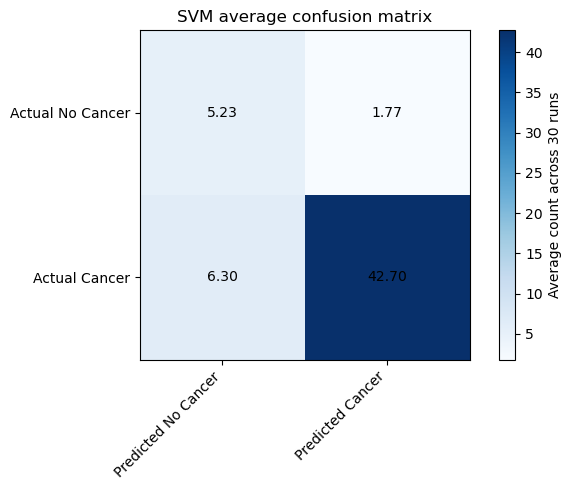


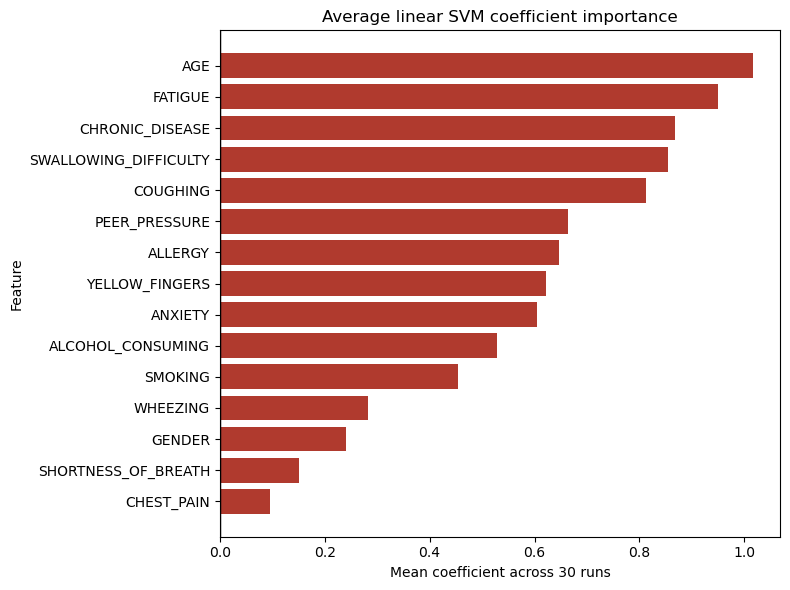

In [46]:
from time import perf_counter
from sklearn.svm import SVC

svm_original_predictor_columns = [
    column_name
    for column_name in dataset_clean.columns
    if column_name not in ['LUNG_CANCER', 'BATCH_1', 'BATCH_2', 'BATCH_3', 'AGE_BINS']
]
svm_features = dataset_clean[svm_original_predictor_columns].copy()
svm_target = dataset_clean['LUNG_CANCER'].copy()

svm_age_features = ['AGE']
svm_other_numeric_features = [
    column_name for column_name in svm_original_predictor_columns if column_name not in svm_age_features
]
svm_transformed_feature_names = svm_age_features + svm_other_numeric_features

svm_preprocess = ColumnTransformer(
    transformers=[
        (
            'age',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('scaler', MinMaxScaler()),
                ]
            ),
            svm_age_features,
        ),
        (
            'numeric',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('scaler', StandardScaler()),
                ]
            ),
            svm_other_numeric_features,
        ),
    ]
)

svm_model_kwargs = {
    'kernel': 'linear',
    'C': 1.0,
    'class_weight': 'balanced',
}
svm_random_seeds = list(range(30))

svm_hyperparameter_df = pd.DataFrame(
    {
        'Setting': [
            'kernel',
            'C',
            'class_weight',
            'stratified hold-out runs',
            'test size',
            'random seed range',
        ],
        'Value': [
            svm_model_kwargs['kernel'],
            f"{svm_model_kwargs['C']:.1f}",
            svm_model_kwargs['class_weight'],
            len(svm_random_seeds),
            '0.2',
            f"{svm_random_seeds[0]}-{svm_random_seeds[-1]}",
        ],
    }
)

svm_run_rows = []
svm_conf_matrices = []
svm_coefficient_rows = []

for svm_random_seed in svm_random_seeds:
    svm_X_train, svm_X_test, svm_y_train, svm_y_test = train_test_split(
        svm_features,
        svm_target,
        test_size=0.2,
        stratify=svm_target,
        random_state=svm_random_seed,
    )

    svm_pipeline = Pipeline(
        steps=[('preprocess', svm_preprocess), ('model', SVC(**svm_model_kwargs))]
    )
    svm_fit_start = perf_counter()
    svm_pipeline.fit(svm_X_train, svm_y_train)
    svm_training_time_seconds = perf_counter() - svm_fit_start

    svm_predictions = svm_pipeline.predict(svm_X_test)
    svm_decision_scores = svm_pipeline.decision_function(svm_X_test)
    svm_conf_matrices.append(
        confusion_matrix(svm_y_test, svm_predictions, labels=[0, 1])
    )
    svm_coefficient_rows.append(
        pd.Series(
            svm_pipeline.named_steps['model'].coef_[0],
            index=svm_transformed_feature_names,
        )
    )
    svm_run_rows.append(
        {
            'Random seed': svm_random_seed,
            'Accuracy': accuracy_score(svm_y_test, svm_predictions),
            'Precision': precision_score(svm_y_test, svm_predictions),
            'Recall': recall_score(svm_y_test, svm_predictions),
            'F2-score': fbeta_score(svm_y_test, svm_predictions, beta=2),
            'ROC-AUC': roc_auc_score(svm_y_test, svm_decision_scores),
            'Training time (seconds)': svm_training_time_seconds,
        }
    )

svm_run_metrics_df = pd.DataFrame(svm_run_rows)
svm_average_conf_matrix = np.mean(svm_conf_matrices, axis=0)
svm_coefficient_df = pd.DataFrame(svm_coefficient_rows)
svm_mean_coefficients = svm_coefficient_df.mean(axis=0)

svm_metrics_df = pd.DataFrame(
    {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F2-score', 'ROC-AUC', 'Training time (seconds)'],
        'Average value': [
            f"{svm_run_metrics_df['Accuracy'].mean():.4f}",
            f"{svm_run_metrics_df['Precision'].mean():.4f}",
            f"{svm_run_metrics_df['Recall'].mean():.4f}",
            f"{svm_run_metrics_df['F2-score'].mean():.4f}",
            f"{svm_run_metrics_df['ROC-AUC'].mean():.4f}",
            f"{svm_run_metrics_df['Training time (seconds)'].mean():.4f}",
        ],
    }
)

svm_confusion_matrix_df = pd.DataFrame(
    svm_average_conf_matrix,
    index=['Actual No Cancer', 'Actual Cancer'],
    columns=['Predicted No Cancer', 'Predicted Cancer'],
).round(2)

svm_average_coefficients_df = (
    pd.DataFrame(
        {
            'Feature': svm_mean_coefficients.index,
            'Mean coefficient': svm_mean_coefficients.values,
        }
    )
    .assign(**{'Absolute mean coefficient': lambda df: df['Mean coefficient'].abs()})
    .sort_values('Absolute mean coefficient', ascending=False)
    .reset_index(drop=True)
    .round(4)
)

if HTML is not None and display is not None:
    display(HTML(_render_centered_html_table(
        svm_hyperparameter_df,
        'Table 8, Linear SVM hyperparameters and evaluation settings',
        width='58%',
    )))
    display(HTML(_render_centered_html_table(
        svm_metrics_df,
        'Table 9, Linear SVM average hold-out performance metrics across 30 runs',
        width='58%',
    )))
else:
    print(svm_hyperparameter_df.to_string(index=False))
    print(svm_metrics_df.to_string(index=False))
    print(svm_confusion_matrix_df.to_string(index=False))
    print(svm_average_coefficients_df.to_string(index=False))


def _display_centered_matplotlib_figure(figure, max_width='72%', caption=None):
    if HTML is not None and display is not None:
        import base64
        from io import BytesIO

        buffer = BytesIO()
        figure.savefig(
            buffer,
            format='png',
            bbox_inches='tight',
        )
        buffer.seek(0)
        figure_base64 = base64.b64encode(buffer.read()).decode('utf-8')
        plt.close(figure)
        display(HTML(
            "<div style='width: 100%; text-align: center;'>"
            f"<img src='data:image/png;base64,{figure_base64}' "
            f"style='display: block; margin: 0 auto; max-width: {max_width}; height: auto;'/>"
            f"<p style='text-align: center; margin-top: 8px; color: #000000;'><em>{caption}</em></p>" if caption else ""
            "</div>"
        ))
    else:
        plt.show()
        if caption:
            print(caption)


svm_confusion_fig, svm_confusion_ax = plt.subplots(figsize=(7, 5))
svm_confusion_image = svm_confusion_ax.imshow(svm_confusion_matrix_df.values, cmap='Blues')
svm_confusion_fig.colorbar(
    svm_confusion_image,
    ax=svm_confusion_ax,
    label='Average count across 30 runs',
)
svm_confusion_ax.set_xticks(range(len(svm_confusion_matrix_df.columns)))
svm_confusion_ax.set_xticklabels(
    svm_confusion_matrix_df.columns,
    rotation=45,
    ha='right',
)
svm_confusion_ax.set_yticks(range(len(svm_confusion_matrix_df.index)))
svm_confusion_ax.set_yticklabels(svm_confusion_matrix_df.index)
svm_confusion_ax.set_title('SVM average confusion matrix')

for row_index in range(len(svm_confusion_matrix_df.index)):
    for column_index in range(len(svm_confusion_matrix_df.columns)):
        svm_confusion_ax.text(
            column_index,
            row_index,
            f"{svm_confusion_matrix_df.iloc[row_index, column_index]:.2f}",
            ha='center',
            va='center',
            color='black',
        )

svm_confusion_fig.tight_layout()
_display_centered_matplotlib_figure(
    svm_confusion_fig,
    caption='Figure 4. SVM average confusion matrix across 30 stratified hold-out runs.',
)

svm_coefficient_plot_df = svm_average_coefficients_df.copy()
svm_coefficient_colors = [
    '#b03a2e' if coefficient > 0 else '#2874a6'
    for coefficient in svm_coefficient_plot_df['Mean coefficient']
]

svm_coefficient_fig, svm_coefficient_ax = plt.subplots(figsize=(8, 6))
svm_coefficient_ax.barh(
    svm_coefficient_plot_df['Feature'],
    svm_coefficient_plot_df['Mean coefficient'],
    color=svm_coefficient_colors,
)
svm_coefficient_ax.axvline(0, color='black', linewidth=1)
svm_coefficient_ax.set_title('Average linear SVM coefficient importance')
svm_coefficient_ax.set_xlabel('Mean coefficient across 30 runs')
svm_coefficient_ax.set_ylabel('Feature')
svm_coefficient_ax.invert_yaxis()
svm_coefficient_fig.tight_layout()
_display_centered_matplotlib_figure(
    svm_coefficient_fig,
    max_width='76%',
    caption='Figure 5. Average linear SVM coefficient importance across 30 stratified hold-out runs.',
)


## 3.3 Binary Tree

Code and key notes lives here

### 3.3.1 Binary Tree Performance Metrics

Metrics to report: F2-score, Accuracy, Precision, Confusion Matrix, ROC-AUC, Model training time

## 3.4 Random Forest

Code and key notes lives here

### 3.4.1 Random Forest Performance Metrics

Metrics to report: F2-score, Accuracy, Precision, Confusion Matrix, ROC-AUC, Model training time

## 3.5 ANN

Code and key notes lives here

### 3.5.1 ANN Performance Metrics

Metrics to report: F2-score, Accuracy, Precision, Confusion Matrix, ROC-AUC, Model training time

## 3.6 Logistic Regression 

Code and key notes lives here

### 3.6.1 Logistic Regression Performance Metrics

Metrics to report: F2-score, Accuracy, Precision, Confusion Matrix, ROC-AUC, Model training time

## 3.7 Naive Bayes 

Code and key notes lives here

### 3.7.1 Naive Bayes Performance Metrics

Metrics to report: F2-score, Accuracy, Precision, Confusion Matrix, ROC-AUC, Model training time

## 3.8 Ensemble 

Use a combination of the top two performing models above 
Code and key notes lives here

### 3.8.1 Ensemble Performance Metrics

Metrics to report: F2-score, Accuracy, Precision, Confusion Matrix, ROC-AUC, Model training time

## 3.9 Comparison and conclusions
Which model are we going forwards with and why?

# 4. Data Analysis and Visualisation


### 4.1 Exploratory analysis goals
The exploratory stage focuses on three questions: which variables differ most between positive and negative cases, which predictors move together, and which patterns should influence model choice and metric selection.


### 4.2 Visualisation strategy
The notebook prioritises visuals that explain structure rather than decorate the report. Histograms, boxplots, grouped comparisons, and heatmaps are used to examine class imbalance, age spread, subgroup differences, and correlated symptom clusters.


The plots are supported by targeted statistical checks, especially Welch's t-tests and the correlated-feature batch analysis shown later. The aim is to connect each visual finding to a modelling implication instead of treating EDA as a separate exercise.


#### 4.2.2 Statistical support for visual findings
Welch's t-test was used for numeric and binary-encoded predictors to test whether average values differ between the cancer and non-cancer groups. This does not prove causation, but it helps separate visually interesting patterns from purely noisy ones.


### 4.3 Target distribution
The target is clearly imbalanced, with far more `YES` than `NO` cases even after removing the final raw-row block. That imbalance directly affects later metric choice and supports treating recall and F1-score as more informative than accuracy alone.


#### 4.3.1 Class imbalance check
Yes, the imbalance matters. A model could appear strong by leaning too heavily toward the majority class, so the later evaluation emphasises recall, F1-score, and ROC AUC rather than relying on accuracy alone.


## 4.4 Univariate analysis
The univariate step checks the spread of age and the frequency of each binary indicator before looking at the target. This makes it easier to separate genuinely unusual patterns from features that are simply common across the whole sample.


### 4.4.1 Age distribution
Age is concentrated around the late fifties to early seventies, with a few younger and older records at the edges of the sample. That supports keeping `AGE` as a numeric feature, rescaling it to the `0-1` range for modelling, and also using broad bins for descriptive interpretation.


### 4.4.2 Symptom and lifestyle variables
Several symptom-related variables are common in the dataset overall, so raw prevalence alone is not enough. The later target-conditioned comparisons and statistical tests are more useful than the marginal frequencies by themselves.


## 4.5 Bivariate analysis against the target
The bivariate stage focuses on how each predictor changes with the target label. This is the point where exploratory analysis starts to inform feature selection and model choice directly.


In [47]:
from scipy.stats import ttest_ind

alpha = 0.05
engineered_features = ["BATCH_1", "BATCH_2", "BATCH_3"]
excluded_t_test_features = {"LUNG_CANCER", "AGE_BINS"}
t_test_feature_columns = [
    feature_name
    for feature_name in dataset_clean.columns
    if feature_name not in excluded_t_test_features
    and pd.api.types.is_numeric_dtype(dataset_clean[feature_name])
]
no_cancer_group = dataset_clean[dataset_clean["LUNG_CANCER"] == 0]
cancer_group = dataset_clean[dataset_clean["LUNG_CANCER"] == 1]

t_test_results = []
for feature_name in t_test_feature_columns:
    no_cancer_values = no_cancer_group[feature_name].dropna()
    cancer_values = cancer_group[feature_name].dropna()
    t_statistic, p_value = ttest_ind(
        no_cancer_values,
        cancer_values,
        equal_var=False,
        nan_policy="omit",
    )

    is_significant = p_value < alpha
    t_test_results.append(
        {
            "Feature": feature_name,
            "Mean (No Cancer)": no_cancer_values.mean(),
            "Mean (Cancer)": cancer_values.mean(),
            "t-statistic": t_statistic,
            "p-value": p_value,
            "Significant (p < 0.05)": is_significant,
        }
    )

all_t_test_results_df = (
    pd.DataFrame(t_test_results)
    .sort_values("p-value")
    .reset_index(drop=True)
)

original_feature_t_test_results_df = all_t_test_results_df[
    ~all_t_test_results_df["Feature"].isin(engineered_features)
].reset_index(drop=True)
engineered_feature_t_test_results_df = all_t_test_results_df[
    all_t_test_results_df["Feature"].isin(engineered_features)
].reset_index(drop=True)

print("Original feature t-test results")
original_feature_t_test_results_df

print("Engineered feature t-test results")
engineered_feature_t_test_results_df


Original feature t-test results
Engineered feature t-test results


,Feature,Mean (No Cancer),Mean (Cancer),t-statistic,p-value,Significant (p < 0.05)
0,BATCH_2,0.571429,1.836066,-8.253413,5.303774e-11,True
1,BATCH_1,1.057143,2.172131,-6.056036,9.456295e-08,True
2,BATCH_3,1.285714,1.959016,-3.852247,3.595397e-04,True


Welch's independent samples t-tests indicated statistically significant differences between the lung cancer groups for most of the strongest symptom and lifestyle variables. All three batch-derived engineered composites also differed significantly between the two classes, which supports carrying them into the final modelling table.


### 4.5.1 Correlated feature batches
This follow-up step ignores `LUNG_CANCER` and instead looks at how strongly the original tested features relate to one another. The engineered features were removed from this stage so the batches reflect only the raw variables used in the dataset. The remaining numeric features were ranked by their average absolute correlation with every other original tested variable, then the top 12 were grouped into batches of four that maximise within-batch correlation. These batches later inform the three engineered composite features, with `GENDER` left as a standalone variable for interpretability and `WHEEZING` excluded from the third composite because it showed the weakest within-batch correlation.


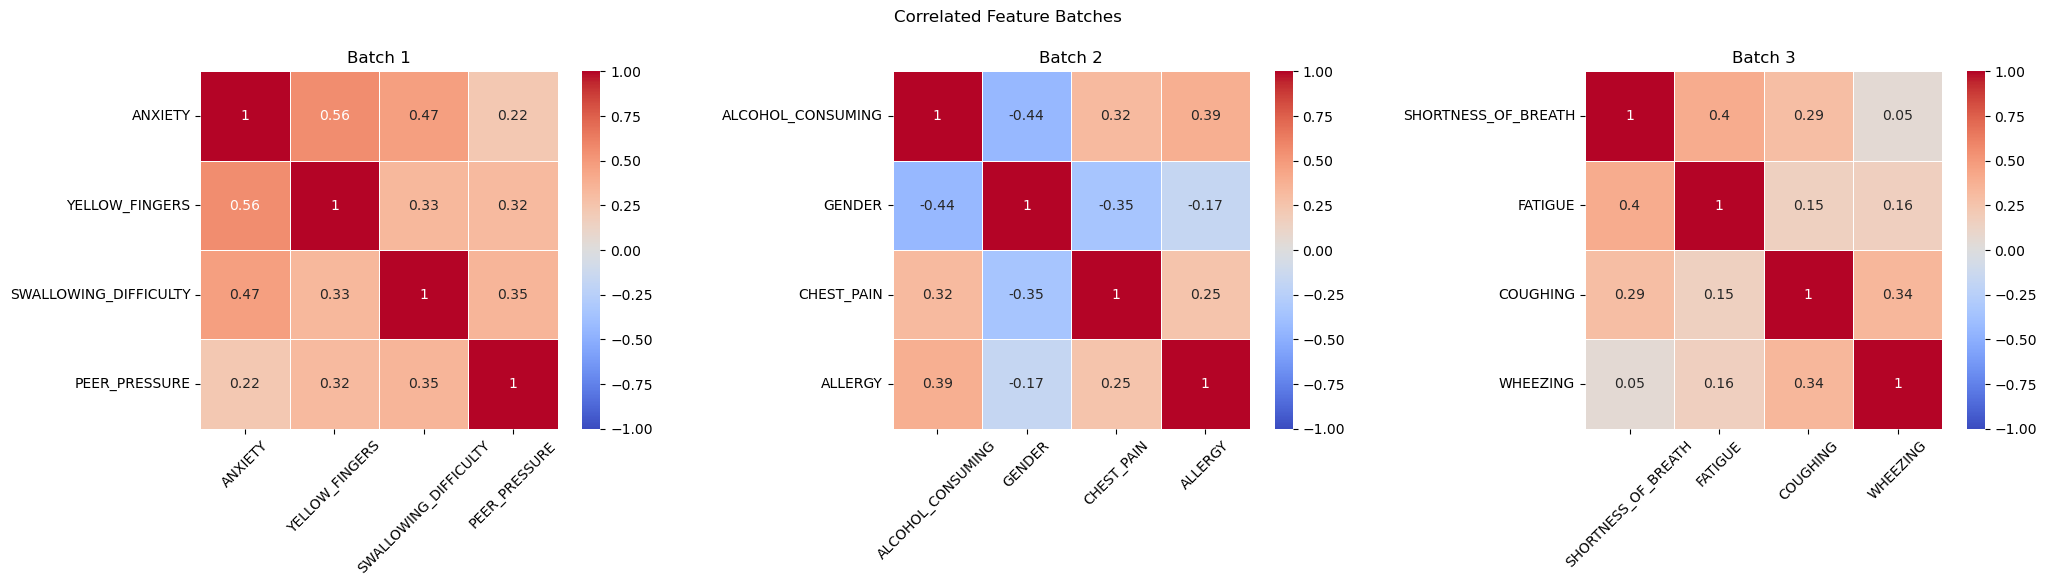

In [48]:
intercorrelation_feature_columns = [
    feature_name
    for feature_name in t_test_feature_columns
    if feature_name not in engineered_features
]

feature_signed_correlation_matrix = dataset_clean[intercorrelation_feature_columns].corr()
feature_peer_correlation_matrix = feature_signed_correlation_matrix.abs()
feature_mean_peer_correlation = (
    (feature_peer_correlation_matrix.sum(axis=1) - 1)
    / (len(intercorrelation_feature_columns) - 1)
).sort_values(ascending=False)

top_intercorrelated_features = feature_mean_peer_correlation.head(12).index.tolist()
batch_size = 4
batch_columns = [
    "Feature",
    "Mean absolute correlation with other tested features",
    "Mean absolute correlation within batch",
    "Mean (No Cancer)",
    "Mean (Cancer)",
    "t-statistic",
    "p-value",
    "Significant (p < 0.05)",
]

remaining_features = top_intercorrelated_features.copy()
batch_results_list = []
batch_feature_sets = []

while len(remaining_features) >= batch_size:
    best_pair = None
    best_pair_correlation = -1
    for left_index, left_feature in enumerate(remaining_features):
        for right_feature in remaining_features[left_index + 1:]:
            pair_correlation = feature_peer_correlation_matrix.loc[left_feature, right_feature]
            if pair_correlation > best_pair_correlation:
                best_pair_correlation = pair_correlation
                best_pair = [left_feature, right_feature]

    current_batch = best_pair.copy()
    candidate_features = [
        feature_name for feature_name in remaining_features if feature_name not in current_batch
    ]

    while len(current_batch) < batch_size and candidate_features:
        next_feature = max(
            candidate_features,
            key=lambda feature_name: sum(
                feature_peer_correlation_matrix.loc[feature_name, grouped_feature]
                for grouped_feature in current_batch
            ) / len(current_batch),
        )
        current_batch.append(next_feature)
        candidate_features.remove(next_feature)

    batch_correlation_matrix = feature_peer_correlation_matrix.loc[current_batch, current_batch]
    batch_mean_correlation = (
        batch_correlation_matrix.values.sum() - len(current_batch)
    ) / (len(current_batch) * (len(current_batch) - 1))

    batch_results = all_t_test_results_df[
        all_t_test_results_df["Feature"].isin(current_batch)
    ].copy()
    batch_results["Mean absolute correlation with other tested features"] = batch_results[
        "Feature"
    ].map(feature_mean_peer_correlation)
    batch_results["Mean absolute correlation within batch"] = batch_results["Feature"].map(
        lambda feature_name: batch_correlation_matrix.loc[feature_name].drop(feature_name).mean()
    )
    batch_results["Batch mean absolute correlation"] = batch_mean_correlation
    batch_results_list.append(batch_results)
    batch_feature_sets.append(
        {
            "features": current_batch,
            "batch_mean_absolute_correlation": batch_mean_correlation,
        }
    )

    remaining_features = [
        feature_name for feature_name in remaining_features if feature_name not in current_batch
    ]

correlated_feature_batches_df = pd.concat(batch_results_list, ignore_index=True)
batch_order = (
    correlated_feature_batches_df[["Batch mean absolute correlation"]]
    .drop_duplicates()
    .sort_values("Batch mean absolute correlation", ascending=False)
    .reset_index(drop=True)
)
batch_label_map = {
    batch_mean: f"Batch {batch_number}"
    for batch_number, batch_mean in enumerate(
        batch_order["Batch mean absolute correlation"],
        start=1,
    )
}
correlated_feature_batches_df["Batch"] = correlated_feature_batches_df[
    "Batch mean absolute correlation"
].map(batch_label_map)
batch_feature_map = {
    batch_label_map[batch_definition["batch_mean_absolute_correlation"]]: batch_definition[
        "features"
    ]
    for batch_definition in batch_feature_sets
}
batch_correlation_matrices = {
    batch_name: feature_signed_correlation_matrix.loc[feature_list, feature_list].round(2)
    for batch_name, feature_list in batch_feature_map.items()
}
correlated_feature_batches_df = correlated_feature_batches_df[
    [
        "Batch",
        "Feature",
        "Mean absolute correlation with other tested features",
        "Mean absolute correlation within batch",
        "Mean (No Cancer)",
        "Mean (Cancer)",
        "t-statistic",
        "p-value",
        "Significant (p < 0.05)",
    ]
]
correlated_feature_batches_df = correlated_feature_batches_df.sort_values(
    ["Batch", "Mean absolute correlation within batch"],
    ascending=[True, False],
).reset_index(drop=True)

ordered_batch_names = sorted(batch_correlation_matrices)
fig, axes = plt.subplots(1, len(ordered_batch_names), figsize=(7 * len(ordered_batch_names), 5.5))
if len(ordered_batch_names) == 1:
    axes = [axes]

for axis, batch_name in zip(axes, ordered_batch_names):
    sns.heatmap(
        batch_correlation_matrices[batch_name],
        ax=axis,
        annot=True,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar=True,
    )
    axis.set_title(batch_name)
    axis.tick_params(axis="x", rotation=45)
    axis.tick_params(axis="y", rotation=0)

plt.suptitle("Correlated Feature Batches", y=1.02)
plt.tight_layout()
plt.show()


### 4.5.2 Categorical/binary features vs lung cancer
The binary feature comparisons show that several symptom and lifestyle indicators are elevated in the positive class. This supports testing flexible non-linear models, because many of these signals are likely to interact rather than act independently.


### 4.5.3 Age vs lung cancer
Age shows a weaker and more graded relationship with the target than the strongest symptom features. That makes age useful context rather than the single dominant predictor in the modelling stage.


### 4.5.4 Gender subgroup analysis
The gender subgroup plots are descriptive rather than definitive because the dataset is small. They are still useful for checking whether the main symptom patterns appear broadly similar across the two recorded groups.


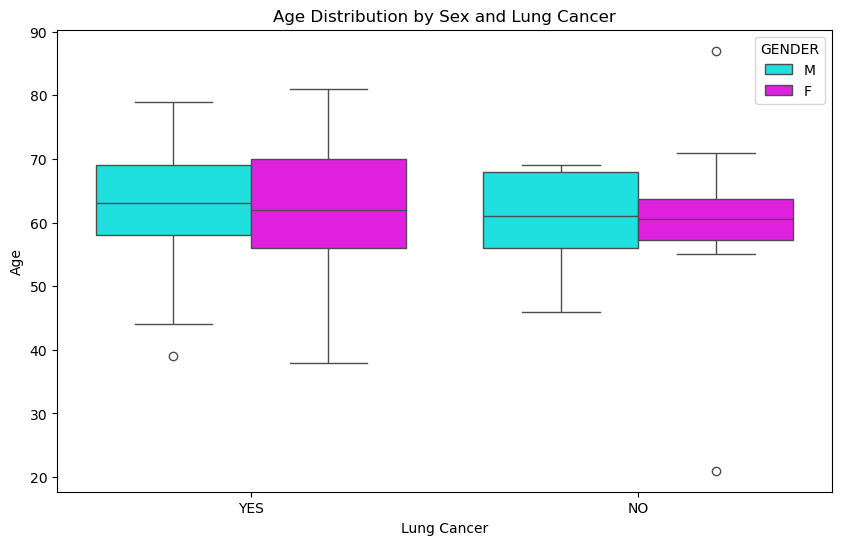

In [49]:
# Check dataset shape, column names, data types, and summary info
plt.figure(figsize=(10,6))
sns.boxplot(data=dataset, x='LUNG_CANCER', y='AGE', hue='GENDER', palette={'M': 'cyan', 'F': 'magenta'})
plt.title("Age Distribution by Sex and Lung Cancer")
plt.xlabel("Lung Cancer")
plt.ylabel("Age")
plt.show()

## 4.6 Correlation and multicollinearity review
The correlation review checks whether the strongest features are also redundant with one another. That matters because highly related symptom variables can inflate the apparent amount of signal without truly adding independent information.


### 4.6.1 Feature relationships
Several respiratory and lifestyle variables move together, which is expected because symptoms such as wheezing, coughing, and shortness of breath often cluster. This pattern motivated the batch-derived composite features and supports testing tree-based models that can exploit interactions.


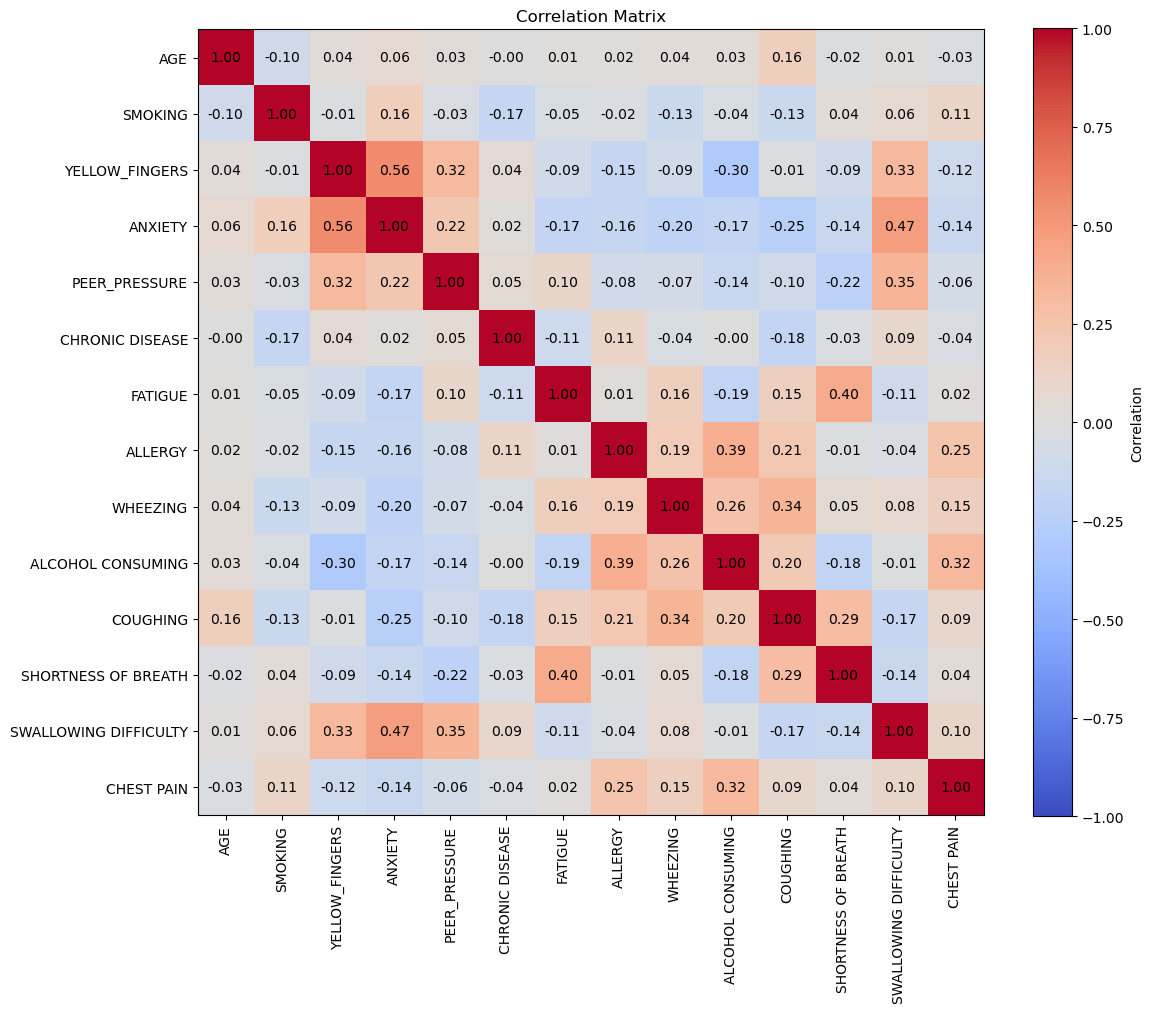

In [50]:
corr_matrix = dataset_dedup.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title('Correlation Matrix')

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.tight_layout()
plt.show()


### 4.6.2 Implications for modelling
Because the predictors are partly correlated and largely binary, both a regularised linear baseline and non-linear tree ensembles are reasonable candidates. The shared pipeline later keeps preprocessing constant so that the comparison focuses on model behaviour rather than data handling differences, while the batch-derived composites give the models a compact summary of correlated groups without replacing the original variables entirely.


## 4.7 Interpretation of key patterns
The strongest patterns point to correlated symptom clusters rather than isolated single variables. That supports building modest batch-based composite features and argues against over-interpreting any one predictor on its own.


## 4.8 Visual insights that inform the ML strategy
The EDA suggests three modelling choices: preserve recall as a priority because the classes are imbalanced, test non-linear models because several features appear to interact, and keep the feature engineering interpretable because the dataset is small.


## 4.9 Data analysis summary
Overall, the EDA shows a small but structured dataset with meaningful duplicate issues, strong symptom-driven separation, and non-trivial feature correlation. Those findings support a leakage-safe comparison between a simple linear model and more flexible ensemble classifiers.


## 4.10 Feature engineering decisions
This section turns the univariate and bivariate findings into the final feature choices used in modelling.

### 4.10.1 Batch-derived composite features
The bivariate testing showed that `BATCH_1`, `BATCH_2`, and `BATCH_3` all separate the two target groups, while Section 4.5.1 showed that their underlying variables form meaningful correlated clusters. Together, those results justify keeping the three batch-derived composites in the final modelling table as compact summaries of related symptom and lifestyle patterns, without removing the original predictors that preserve interpretability.

### 4.10.2 Age representation
The age plots suggested a gradual pattern rather than a single natural cut-off, so the final table keeps both representations of age. `AGE` is retained as a numeric variable and later min-max normalised inside the shared preprocessing pipeline, while `AGE_BINS` is kept as a grouped categorical feature to preserve the more interpretable banded view seen in the EDA.

### 4.10.3 Additional engineered features not retained
No extra ad hoc interactions or broad composite scores were added beyond these features. The EDA supported a restrained approach: keep the original predictors, add only the three correlation-based batch summaries plus `AGE_BINS`, and avoid creating extra variables that the exploratory evidence did not clearly justify.

### 4.10.4 Final modelling table
The final modelling table therefore keeps the original predictors alongside `BATCH_1`, `BATCH_2`, `BATCH_3`, and `AGE_BINS`, with all fitted preprocessing still applied later inside the modelling pipeline.


# 5. Model Selection and Training


## 5.1 Modelling approach
We compared one linear baseline and two tree-based models on the same cleaned feature table. Evaluation combines stratified cross-validation with a final stratified hold-out split so that ranking is fair and the class balance is preserved as much as possible.


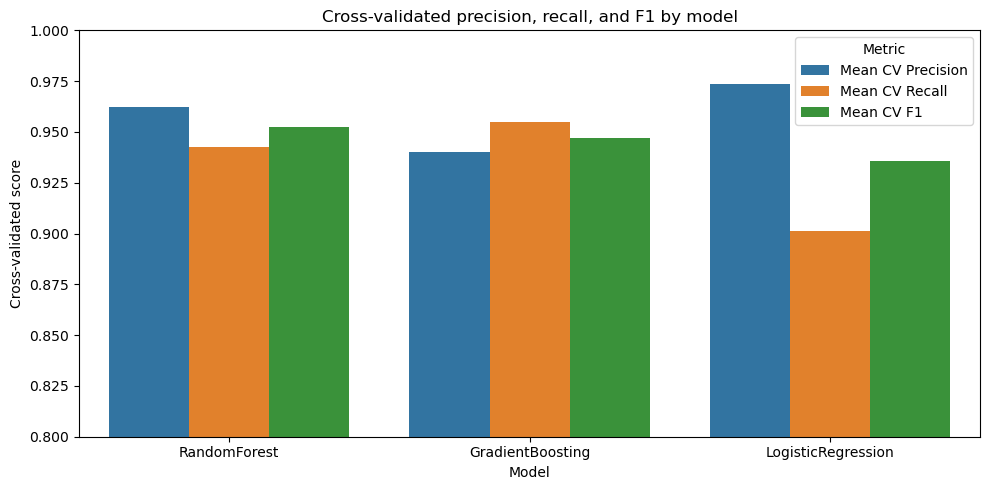

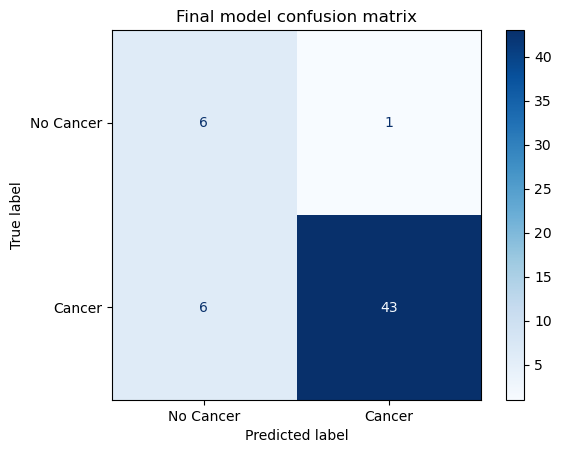

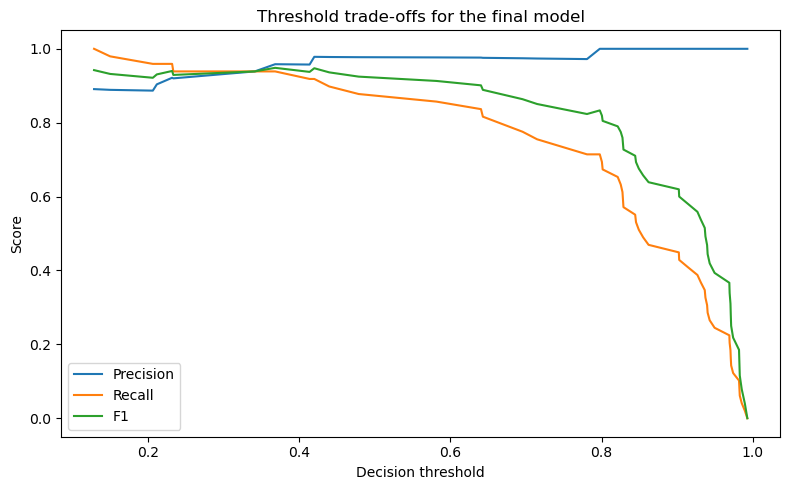

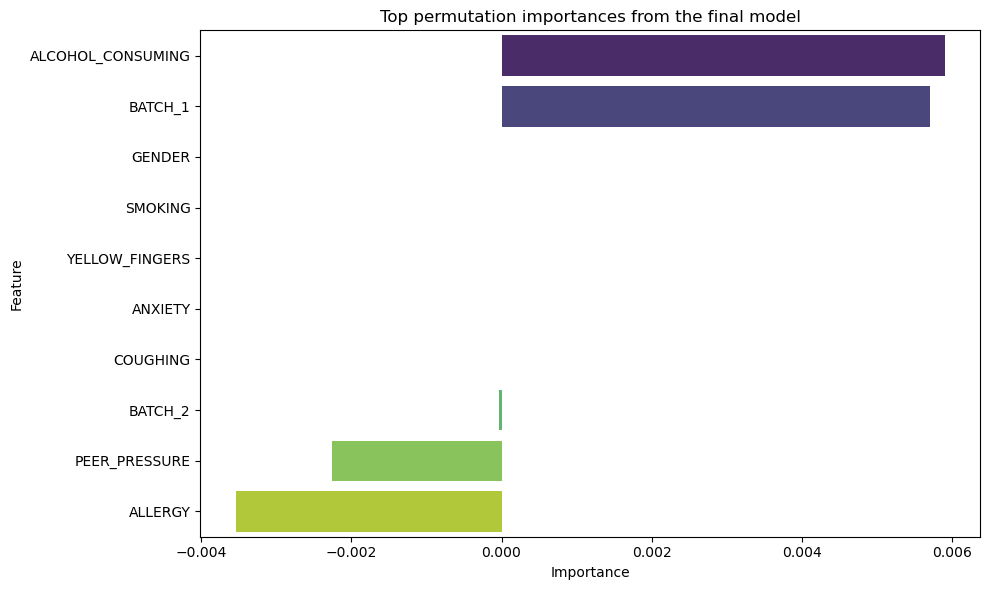

,Gender,Sample Size,False Positives,False Negatives,Recall
0,Male,31,0,4,0.8519
1,Female,25,1,2,0.9091


In [51]:
features = model_dataset.drop(columns=['LUNG_CANCER'])
target = model_dataset['LUNG_CANCER']

numeric_features = [column_name for column_name in features.columns if column_name != 'AGE_BINS']
age_features = ['AGE']
other_numeric_features = [
    column_name for column_name in numeric_features if column_name not in age_features
]
categorical_features = ['AGE_BINS']

preprocess = ColumnTransformer(
    transformers=[
        (
            'age',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('scaler', MinMaxScaler()),
                ]
            ),
            age_features,
        ),
        (
            'numeric',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('scaler', StandardScaler()),
                ]
            ),
            other_numeric_features,
        ),
        (
            'categorical',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                ]
            ),
            categorical_features,
        ),
    ]
)

candidate_models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for model_name, model in candidate_models.items():
    model_pipeline = Pipeline(steps=[('preprocess', preprocess), ('model', model)])
    cv_scores = cross_validate(
        model_pipeline,
        features,
        target,
        cv=cv,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    )
    cv_rows.append(
        {
            'Model': model_name,
            'Mean CV Accuracy': cv_scores['test_accuracy'].mean(),
            'Mean CV Precision': cv_scores['test_precision'].mean(),
            'Mean CV Recall': cv_scores['test_recall'].mean(),
            'Mean CV F1': cv_scores['test_f1'].mean(),
            'Mean CV ROC AUC': cv_scores['test_roc_auc'].mean(),
        }
    )

model_comparison_df = (
    pd.DataFrame(cv_rows)
    .sort_values(['Mean CV F1', 'Mean CV Recall'], ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=model_comparison_df.melt(id_vars='Model', value_vars=['Mean CV Precision', 'Mean CV Recall', 'Mean CV F1']),
    x='Model',
    y='value',
    hue='variable',
)
plt.ylim(0.8, 1.0)
plt.ylabel('Cross-validated score')
plt.xlabel('Model')
plt.title('Cross-validated precision, recall, and F1 by model')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

final_model_name = model_comparison_df.loc[0, 'Model']

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    stratify=target,
    random_state=42,
)

final_pipeline = Pipeline(
    steps=[('preprocess', preprocess), ('model', candidate_models[final_model_name])]
)
final_pipeline.fit(X_train, y_train)

final_predictions = final_pipeline.predict(X_test)
final_probabilities = final_pipeline.predict_proba(X_test)[:, 1]

final_metrics_df = pd.DataFrame(
    [
        {
            'Accuracy': accuracy_score(y_test, final_predictions),
            'Precision': precision_score(y_test, final_predictions),
            'Recall': recall_score(y_test, final_predictions),
            'F1': f1_score(y_test, final_predictions),
            'ROC AUC': roc_auc_score(y_test, final_probabilities),
        }
    ]
).round(4)

conf_matrix = confusion_matrix(y_test, final_predictions, labels=[0, 1])
confusion_matrix_df = pd.DataFrame(
    conf_matrix,
    index=['Actual No Cancer', 'Actual Cancer'],
    columns=['Predicted No Cancer', 'Predicted Cancer'],
)

ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['No Cancer', 'Cancer']).plot(cmap='Blues')
plt.title('Final model confusion matrix')
plt.show()

precision_curve, recall_curve, threshold_values = precision_recall_curve(y_test, final_probabilities)
threshold_analysis_df = pd.DataFrame(
    {
        'Threshold': threshold_values,
        'Precision': precision_curve[1:],
        'Recall': recall_curve[1:],
    }
)
threshold_analysis_df['F1'] = (
    2
    * threshold_analysis_df['Precision']
    * threshold_analysis_df['Recall']
    / np.maximum(
        threshold_analysis_df['Precision'] + threshold_analysis_df['Recall'],
        1e-9,
    )
)
threshold_analysis_df = threshold_analysis_df.round(4)
high_recall_threshold_df = (
    threshold_analysis_df[threshold_analysis_df['Recall'] >= 0.95]
    .sort_values(['Precision', 'F1'], ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(8, 5))
plt.plot(threshold_analysis_df['Threshold'], threshold_analysis_df['Precision'], label='Precision')
plt.plot(threshold_analysis_df['Threshold'], threshold_analysis_df['Recall'], label='Recall')
plt.plot(threshold_analysis_df['Threshold'], threshold_analysis_df['F1'], label='F1')
plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.title('Threshold trade-offs for the final model')
plt.legend()
plt.tight_layout()
plt.show()

permutation_scores = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring='f1',
)
feature_importance_df = (
    pd.DataFrame(
        {
            'Feature': features.columns,
            'Importance': permutation_scores.importances_mean,
        }
    )
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(10),
    x='Importance',
    y='Feature',
    hue='Feature',
    dodge=False,
    palette='viridis',
)
plt.legend([], [], frameon=False)
plt.title('Top permutation importances from the final model')
plt.tight_layout()
plt.show()

error_analysis_df = X_test[['GENDER']].copy()
error_analysis_df['Actual'] = y_test.values
error_analysis_df['Predicted'] = final_predictions

subgroup_rows = []
for gender_value, gender_label in [(0, 'Male'), (1, 'Female')]:
    subgroup = error_analysis_df[error_analysis_df['GENDER'] == gender_value]
    subgroup_conf_matrix = confusion_matrix(subgroup['Actual'], subgroup['Predicted'], labels=[0, 1])
    subgroup_rows.append(
        {
            'Gender': gender_label,
            'Sample Size': int(len(subgroup)),
            'False Positives': int(subgroup_conf_matrix[0, 1]),
            'False Negatives': int(subgroup_conf_matrix[1, 0]),
            'Recall': recall_score(subgroup['Actual'], subgroup['Predicted']),
        }
    )

subgroup_error_df = pd.DataFrame(subgroup_rows).round(4)

model_comparison_df = model_comparison_df.round(4)
feature_importance_df = feature_importance_df.round(4)

model_comparison_df
final_metrics_df
confusion_matrix_df
high_recall_threshold_df.head()
feature_importance_df.head(10)
subgroup_error_df


### 5.1.1 Cross-validation strategy
The notebook uses a stratified 80/20 train-test split for final reporting and 5-fold `StratifiedKFold` cross-validation during model comparison. Stratification keeps the `YES`/`NO` balance similar across folds, which matters because the dataset is small and clearly skewed toward positive cases.


### 5.1.2 Metric priority
Recall and F1-score were prioritised over accuracy alone. In a health-related screening context, missing a positive case is more concerning than raising some false alarms, but precision still matters because excessive false positives reduce credibility.


## 5.2 Baseline model
Logistic regression serves as the baseline because it is simple, interpretable, and well suited to small tabular datasets. Its performance provides a sensible reference before testing more flexible non-linear models.


## 5.3 Candidate models
Three candidates were compared: logistic regression, random forest, and gradient boosting. The linear model tests whether the signal is mostly additive, while the tree ensembles capture interactions and non-linear thresholds without heavy manual feature search.


## 5.4 Training decisions
All models use the same cleaned feature set and the same preprocessing pipeline, with `AGE` min-max normalised to the `0-1` range, age-band one-hot encoding, and other fitted transformations applied inside the pipeline. This keeps the comparison fair and leakage-safe while allowing the engineered batch composites to complement the original binary predictors.


### 5.4.1 Feature set used
The final feature table keeps the original predictors alongside `BATCH_1`, `BATCH_2`, `BATCH_3`, and `AGE_BINS`. `AGE` is min-max normalised to the `0-1` range inside preprocessing, while these three engineered features come directly from the correlation batches identified in Section 4.5.1, with `WHEEZING` excluded from the third composite because its within-batch correlation was notably weaker than the other members.


### 5.4.2 Hyperparameter tuning
The random forest was given a moderate depth limit and minimum leaf size rather than aggressive tuning. That choice reduces overfitting risk on a 279-row dataset while still allowing the model to learn useful interactions.


### 5.4.3 Class imbalance handling
Class imbalance was handled with `class_weight='balanced'` for logistic regression and random forest. Gradient boosting was left unweighted and included as a contrast so that the effect of class reweighting is visible in the comparison.


### 5.4.4 Data pipelines
Each candidate model sits inside a scikit-learn pipeline with a shared `ColumnTransformer`. That means age normalisation, imputation, and one-hot encoding are fitted only on training data within each cross-validation fold and within the final training split.


## 5.5 Model iteration log

| Revision | Change | Summary | Evidence |
| --- | --- | --- | --- |
| 1 | Engineered-feature cleanup | Removed the deprecated `LIFESTYLE_RISK`, `HEAVY_SMOKER`, and `RESPIRATORY_DISTRESS` features so the final table no longer mixed overlapping ad hoc constructs with the original predictors. | Reduced duplication, avoided loosely justified interactions, and kept the feature set easier to interpret. |
| 2 | Batch-derived feature revision | Replaced the earlier broad composite with `BATCH_1`, `BATCH_2`, and `BATCH_3`, each tied to the Section 4.5.1 correlation batches. | Stronger alignment with the observed correlation structure and clearer traceability to the EDA. |
| 3 | Age feature revision | Kept `AGE` as a numeric predictor but normalised it to the `0-1` range inside preprocessing while retaining `AGE_BINS` for grouped interpretation. | Preserved an interpretable age signal while giving scale-sensitive models a consistent numeric range. |


### 5.5.1 First-pass model results
The logistic-regression baseline achieved high precision but lower recall and F1-score than the tree ensembles. It therefore worked well as a benchmark rather than as the final choice.


### 5.5.2 What was adjusted
The main changes were the removal of deprecated ad hoc engineered variables, the switch from one broad composite feature to three batch-derived composite features, and the normalisation of `AGE` inside preprocessing while retaining `AGE_BINS` for grouped interpretation. Together, these revisions keep the feature set more interpretable and more directly tied to the observed correlation structure.


### 5.5.3 Why the adjustment was made
Each adjustment was driven by the trade-off between recall, F1-score, and overfitting risk. The final notebook favours a model that improves detection of positive cases while remaining stable across folds.


## 5.6 Model comparison plan
Models are compared on the same feature table, the same shared preprocessing steps, and the same stratified 5-fold splits. Ranking uses recall and F1-score first, with precision, ROC AUC, and hold-out behaviour used as tie-breakers.


## 5.7 Final model choice
Random forest was selected as the final model. It delivered the highest mean cross-validated F1-score (`0.9523`), strong recall (`0.9425`), and the strongest overall balance across the comparison table, so it remained the most defensible final choice under the revised row-trimming rule.

---


# 6. Results and Analysis


## 6.1 Performance metrics



### 6.1.1 Core classification metrics
On the hold-out split, the final random forest achieved accuracy `0.8750`, precision `0.9773`, recall `0.8776`, F1-score `0.9247`, and ROC AUC `0.9184`. These results still indicate useful predictive signal, but they are more modest once the notebook keeps the earlier repeated rows and removes only the suspicious final 30-row block.


### 6.1.2 Confusion matrix
The hold-out confusion matrix contains 43 true positives, 6 true negatives, 1 false positive, and 6 false negatives. That pattern still favours correct positive predictions overall, but the missed positive cases remain the more important weakness in a health-related setting.


### 6.1.3 Threshold trade-offs
At the default threshold, the model keeps high hold-out precision at `0.9773`, but recall falls to `0.8776`. Lowering the threshold to roughly `0.23` raises recall to `0.9592` and F1 to `0.9400`, but precision drops to `0.9216`. That trade-off is still useful to show, yet it remains specific to one small split rather than a fixed operating rule.


## 6.2 Model comparison results
Cross-validation still shows a clear ordering. Logistic regression is the most interpretable but least sensitive, gradient boosting remains competitive on recall, and random forest produces the best F1-score with a strong ROC AUC.


## 6.3 Feature importance and model explainability
Permutation importance was used on the hold-out set so the rankings reflect predictive contribution rather than raw tree split frequency.


### 6.3.1 Importance from the final model
The clearest positive permutation-importance signals came from `ALCOHOL_CONSUMING` and `BATCH_1`, while most other variables were close to zero on the hold-out split. This suggests that the predictive signal is concentrated in a small subset of features and that lower-ranked importance values are not stable enough to over-interpret in such a small sample.


### 6.3.2 Interpretation limits
These importance rankings support the coursework question by showing which recorded variables are most useful for predicting the label in this sample. They should be read as dataset-specific associations, not as evidence of medical causation or clinical priority.


## 6.4 Error analysis
The final-model errors now include both false negatives and a single false positive on the hold-out split. Even so, the six missed positive cases remain the more important concern in a screening-style task.


### 6.4.1 False positives
There was one false positive on the hold-out split. That keeps precision high overall, but it also shows why the notebook should report the full error balance rather than claiming near-perfect behaviour from a single small split.


### 6.4.2 False negatives
There were six false negatives on the hold-out split. That is still a minority of the positive cases, but each missed positive would matter in a real health context, which reinforces the need to prioritise recall when comparing models.


### 6.4.3 Subgroup error patterns
On the hold-out split, the male subgroup had four false negatives and no false positives, giving recall of `0.8519` across 31 cases. The female subgroup had two false negatives and one false positive, giving recall of `0.9091` across 25 cases. These subgroup counts are still too small to support strong fairness claims, but the comparison remains useful for transparency.


## 6.5 Critical discussion
The results are promising for this dataset, but they need clear limits around sample size, duplicate structure, and the non-clinical nature of the source data.


### 6.5.1 Strengths
- The final model still combines high hold-out precision with a solid F1-score.
- The preprocessing workflow is reproducible and leakage-aware.
- The engineered features now follow directly from the correlation analysis rather than from ad hoc grouping.


### 6.5.2 Limitations
- Only 279 rows remain after excluding the suspicious final 30-row block, so metric estimates are still noisy.
- Earlier repeated records were retained by design, so results are sensitive to the chosen cleaning rule.
- The dataset is imbalanced and unlikely to represent a real screening population.
- The symptoms and target are observational rather than clinical proof, so the model cannot support causal or medical claims.


### 6.5.3 Fairness and bias considerations
The limited hold-out subgroup check did not show a large disparity, but the sample is far too small to certify fairness. In addition, the source data stores gender in a simple binary form and provides no broader demographic coverage, which further restricts interpretation.


#### 6.5.4 Improvement ideas
- Validate the workflow on an external dataset with clearer provenance.
- Use repeated or nested validation for more stable model selection.
- Explore calibrated probabilities and threshold-setting with an explicit cost model for false negatives and false positives.


## 6.6 Results summary
Across the tested models, random forest remained the best overall compromise. It improved on the logistic baseline, retained very high precision and F1-score, and did so with engineered features that map directly to the main correlated batches in the EDA.


# 7. Final Conclusion


### 7.1 Direct answer to the brief
Yes, this dataset supports a supervised classification model that predicts `LUNG_CANCER` reasonably well within the limits of a coursework exercise. A random forest trained on the cleaned and tail-trimmed data produced the strongest balance of recall, F1-score, and ROC AUC, making it the best candidate among the tested models.


### 7.2 Reflection
The clearest lesson from the workflow is that data preparation mattered as much as model choice. Making the row-exclusion rule explicit, keeping feature engineering cautious, and using leakage-safe evaluation improved the credibility of the results more than aggressive tuning would have, and tying the engineered features back to the observed correlation batches made the final design easier to justify.

---


<p align="center"><img src="assets/LboroLogoSmall.png" alt="Loughborough University logo"></p>
